# Part 1: Single-Trial Visualization
Figures 1–3: Understanding the raw motor output before any averaging or modeling.

In [1]:
# =============================================================================
# Setup: imports, data loading, palettes, helper computations
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
ROOT = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
VIGOR_PROC = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_processed'
FIGS_DIR = ROOT / 'figs'
FIGS_DIR.mkdir(parents=True, exist_ok=True)
DPI = 150

# ------------------------------------------------------------------
# Load & filter
# ------------------------------------------------------------------
raw = pd.read_parquet(VIGOR_PROC / 'smoothed_vigor_ts.parquet')
# Harmonize column names
if 'subj' in raw.columns and 'subj_id' not in raw.columns:
    raw = raw.rename(columns={'subj': 'subj_id', 'trial': 'trial_id'})
raw['trial_type'] = 1  # all stage5 data passed QC
df = raw[raw['trial_type'] == 1].copy()
print(f'Loaded {len(raw):,} rows -> filtered to trial_type==1: {len(df):,} rows')
print(f'Unique subjects: {df["subj_id"].nunique()}, '
      f'unique subject-trials: {df.groupby(["subj_id","trial_id"]).ngroups}')

# ------------------------------------------------------------------
# Color palettes
# ------------------------------------------------------------------
THREAT_COLORS = {0.1: '#2ca02c', 0.5: '#ff7f0e', 0.9: '#d62728'}
CHOICE_COLORS = {0: 'steelblue', 1: 'darkorange'}
DISTANCE_COLORS = {1: '#aec7e8', 2: '#1f77b4', 3: '#08306b'}
OUTCOME_COLORS = {'escaped': '#2ca02c', 'captured': '#d62728'}
TIER_COLORS = {0: '#d9d9d9', 1: '#969696', 2: '#636363', 3: '#252525'}
TIER_LABELS = {0: 'Tier 0 (<25% r_min)', 1: 'Tier 1 (25-50%)',
               2: 'Tier 2 (50-100%)', 3: 'Tier 3 (>=100%)'}

# ------------------------------------------------------------------
# Speed-tier classification
# ------------------------------------------------------------------
def classify_speed_tier(v, r_min):
    """Return tier index 0-3 based on v relative to r_min."""
    if r_min <= 0:
        return 0
    ratio = v / r_min
    if ratio < 0.25:
        return 0
    elif ratio < 0.50:
        return 1
    elif ratio < 1.00:
        return 2
    else:
        return 3

# Vectorised version for the full dataframe
def classify_speed_tier_vec(v, r_min):
    """Vectorised speed tier classification."""
    ratio = np.where(r_min > 0, v / r_min, 0.0)
    tier = np.zeros(len(v), dtype=int)
    tier[ratio >= 0.25] = 1
    tier[ratio >= 0.50] = 2
    tier[ratio >= 1.00] = 3
    return tier

# ------------------------------------------------------------------
# Terminal time computation
# ------------------------------------------------------------------
def compute_terminal_time(row):
    """Determine the terminal event time for a trial."""
    if row['outcome'] == 0:      # escaped
        return row['escape_time']
    elif row['outcome'] == 1:    # captured
        return row['capture_time']
    else:                        # timed out
        return row['trial_end_time']

# ------------------------------------------------------------------
# Build trial_info: one row per (subj_id, trial_id)
# ------------------------------------------------------------------
trial_info = df.groupby(['subj_id', 'trial_id']).agg(
    threat=('threat', 'first'),
    choice=('choice', 'first'),
    distance_H=('distance_H', 'first'),
    encounter=('encounter', 'first'),
    outcome=('outcome', 'first'),
    encounter_time=('encounter_time', 'first'),
    escape_time=('escape_time', 'first'),
    capture_time=('capture_time', 'first'),
    trial_end_time=('trial_end_time', 'first'),
    startDistance=('startDistance', 'first'),
    effort_H=('effort_H', 'first'),
    effort_L=('effort_L', 'first'),
    f_max_i=('f_max_i', 'first'),
    mean_vigor=('v_t', 'mean'),
).reset_index()

trial_info['terminal_time'] = trial_info.apply(compute_terminal_time, axis=1)
trial_info['r_min'] = np.where(
    trial_info['choice'] == 0,
    trial_info['effort_L'],
    trial_info['effort_H']
)

print(f'trial_info: {len(trial_info):,} trials')
trial_info.head()

Loaded 3,484,910 rows -> filtered to trial_type==1: 1,856,621 rows
Unique subjects: 292, unique subject-trials: 13140
trial_info: 13,140 trials


,subj_id,trial_id,threat,choice,distance_H,encounter,outcome,encounter_time,escape_time,capture_time,trial_end_time,startDistance,effort_H,effort_L,f_max_i,mean_vigor,terminal_time,r_min
0,1,0,0.1,0,3,0,0,2.500000,5.981812,-1.0,15.052216,5,1.0,0.4,4.4,0.313937,5.981812,0.4
1,1,2,0.9,0,2,1,0,2.476318,5.119598,-1.0,5.301697,5,0.8,0.4,4.4,1.030493,5.119598,0.4
2,1,3,0.5,0,3,0,0,2.500000,4.622498,-1.0,15.051331,5,1.0,0.4,4.4,0.279055,4.622498,0.4
3,1,4,0.9,0,3,1,0,2.528992,4.995300,-1.0,5.242981,5,1.0,0.4,4.4,1.030493,4.995300,0.4
4,1,6,0.1,0,2,0,0,2.500000,5.101196,-1.0,15.039856,5,0.8,0.4,4.4,0.313937,5.101196,0.4


In [2]:
# =============================================================================
# Helper: plot a single trial on a given Axes
# =============================================================================
def plot_single_trial(ax, trial_data, trial_meta, show_legend=False):
    """
    Plot one trial's keypress dynamics on a dual-axis panel.

    Parameters
    ----------
    ax : matplotlib Axes
        Left y-axis is used for cumulative keypresses (c_it).
    trial_data : DataFrame
        Time-series rows with columns t, v_t, c_it, d_t.
    trial_meta : dict or Series
        Must contain: encounter_time, terminal_time, outcome, encounter,
        threat, choice, distance_H, r_min.
    show_legend : bool
        Whether to add a legend to the panel.
    """
    td = trial_data.sort_values('t')
    t = td['t'].values
    v = td['v_t'].values
    c = td['c_it'].values
    d = td['d_t'].values

    choice = int(trial_meta['choice'])
    r_min = float(trial_meta['r_min'])
    enc = int(trial_meta['encounter'])
    outcome = int(trial_meta['outcome'])
    enc_time = float(trial_meta['encounter_time'])
    term_time = float(trial_meta['terminal_time'])
    threat = float(trial_meta['threat'])
    dist_h = int(trial_meta['distance_H'])

    # --- Left axis: cumulative keypresses c_it (gray bars) ---
    ax.bar(t, c, width=0.15, color='gray', alpha=0.45, zorder=1, label='c_it')
    ax.set_ylabel('Keypresses (c_it)', color='gray', fontsize=8)
    ax.tick_params(axis='y', labelcolor='gray', labelsize=7)
    ax.tick_params(axis='x', labelsize=7)
    ax.set_xlabel('Time (s)', fontsize=8)

    # --- Right axis: vigor v_t ---
    ax2 = ax.twinx()
    line_color = CHOICE_COLORS[choice]
    ax2.plot(t, v, color=line_color, linewidth=1.2, zorder=3, label='v_t')
    ax2.set_ylabel('Vigor (v_t)', color=line_color, fontsize=8)
    ax2.tick_params(axis='y', labelcolor=line_color, labelsize=7)

    # r_min line
    ax2.axhline(r_min, color='black', linestyle='--', linewidth=0.9,
                alpha=0.8, label=f'r_min={r_min:.2f}')
    # 25% and 50% speed-tier boundaries
    ax2.axhline(0.25 * r_min, color='gray', linestyle='--', linewidth=0.5,
                alpha=0.4)
    ax2.axhline(0.50 * r_min, color='gray', linestyle='--', linewidth=0.5,
                alpha=0.4)

    # Distance trace (scaled to right-axis range)
    v_max = max(v.max(), r_min * 1.2) if len(v) > 0 else 1.0
    d_scaled = d / (d.max() + 1e-9) * v_max * 0.6 if d.max() > 0 else d
    ax2.plot(t, d_scaled, color='gray', linestyle=':', linewidth=0.7,
             alpha=0.5, label='distance (scaled)')

    # --- Vertical event lines ---
    if enc == 1 and enc_time > 0:
        ax.axvline(enc_time, color='orange', linestyle='--', linewidth=1.1,
                   alpha=0.9, zorder=4, label='encounter')

    if outcome == 0:  # escaped
        ax.axvline(term_time, color=OUTCOME_COLORS['escaped'],
                   linestyle='-', linewidth=1.3, zorder=4, label='escaped')
    elif outcome == 1:  # captured
        ax.axvline(term_time, color=OUTCOME_COLORS['captured'],
                   linestyle='-', linewidth=1.3, zorder=4, label='captured')

    # --- Title ---
    atk_str = 'Attack' if enc == 1 else 'No attack'
    out_str = {0: 'Escaped', 1: 'Captured', -1: 'Timeout'}.get(outcome, '?')
    dist_label = f', Dist={dist_h}' if choice == 1 else ''
    ax.set_title(f'Threat={threat}, C={choice}{dist_label}, {atk_str}, {out_str}',
                 fontsize=8, fontweight='bold')

    if show_legend:
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=6,
                  loc='upper right', framealpha=0.7)

    return ax2

print('Helper function plot_single_trial defined.')

Helper function plot_single_trial defined.


## Figure 1: Single-Trial Gallery
Select one median-vigor subject. Display 18+ trials spanning the full design space.
Rows 1-4: choice×threat×distance combinations. Additional panels for non-attack and escaped vs captured.

In [3]:
# =============================================================================
# Select median-vigor subject and curate trials for the gallery
# =============================================================================

# Subject-level mean vigor
subj_vigor = trial_info.groupby('subj_id')['mean_vigor'].mean().reset_index()
subj_vigor.columns = ['subj_id', 'subj_mean_vigor']
median_vigor = subj_vigor['subj_mean_vigor'].median()
subj_vigor['dist_to_median'] = (subj_vigor['subj_mean_vigor'] - median_vigor).abs()
median_subj = subj_vigor.sort_values('dist_to_median').iloc[0]['subj_id']
print(f'Median subject: {median_subj} (mean vigor={subj_vigor.loc[subj_vigor["subj_id"]==median_subj, "subj_mean_vigor"].values[0]:.4f}, '
      f'population median={median_vigor:.4f})')

# Trials for the median subject
subj_trials = trial_info[trial_info['subj_id'] == median_subj].copy()

# Helper: pick a trial matching conditions, preferring attack trials
def pick_trial(pool, choice=None, threat=None, distance_H=None,
               encounter=None, outcome=None):
    """Return trial_id from pool matching filters; prefer attack trials."""
    mask = pd.Series(True, index=pool.index)
    if choice is not None:
        mask &= pool['choice'] == choice
    if threat is not None:
        mask &= pool['threat'] == threat
    if distance_H is not None:
        mask &= pool['distance_H'] == distance_H
    if encounter is not None:
        mask &= pool['encounter'] == encounter
    if outcome is not None:
        mask &= pool['outcome'] == outcome
    subset = pool[mask]
    if len(subset) == 0:
        return None
    # If encounter not forced, prefer attack trials
    if encounter is None:
        attacks = subset[subset['encounter'] == 1]
        if len(attacks) > 0:
            subset = attacks
    # Pick the trial closest to median vigor for this subject
    med_v = subset['mean_vigor'].median()
    idx = (subset['mean_vigor'] - med_v).abs().idxmin()
    return subset.loc[idx]

threats = [0.1, 0.5, 0.9]
distances = [1, 2, 3]

# Build gallery specification: list of (row_label, list-of-trial_meta)
gallery_rows = []

# Row 1: choice=0, 3 threats (prefer attack)
row1 = []
for th in threats:
    tr = pick_trial(subj_trials, choice=0, threat=th)
    row1.append(tr)
gallery_rows.append(('Choice=0 (attack)', row1))

# Rows 2-4: choice=1, threat x distance (prefer attack)
for di in distances:
    row = []
    for th in threats:
        tr = pick_trial(subj_trials, choice=1, threat=th, distance_H=di)
        row.append(tr)
    gallery_rows.append((f'Choice=1, Dist={di} (attack)', row))

# Row 5: non-attack trials (one per threat, choice=0)
row5 = []
for th in threats:
    tr = pick_trial(subj_trials, choice=0, threat=th, encounter=0)
    if tr is None:
        tr = pick_trial(subj_trials, choice=1, threat=th, encounter=0)
    row5.append(tr)
gallery_rows.append(('No-attack', row5))

# Row 6: escaped vs captured (attack trials, any condition)
row6 = []
tr_esc = pick_trial(subj_trials, encounter=1, outcome=0)
tr_cap = pick_trial(subj_trials, encounter=1, outcome=1)
# Pick a second escaped for contrast if available
tr_esc2 = pick_trial(subj_trials, encounter=1, outcome=0, threat=0.9)
row6 = [tr_esc, tr_cap, tr_esc2]
gallery_rows.append(('Escaped vs Captured', row6))

# Count valid panels
n_valid = sum(1 for _, row in gallery_rows for tr in row if tr is not None)
print(f'Gallery: {len(gallery_rows)} rows, {n_valid} valid panels')

Median subject: 104.0 (mean vigor=0.5086, population median=0.5085)
Gallery: 6 rows, 15 valid panels


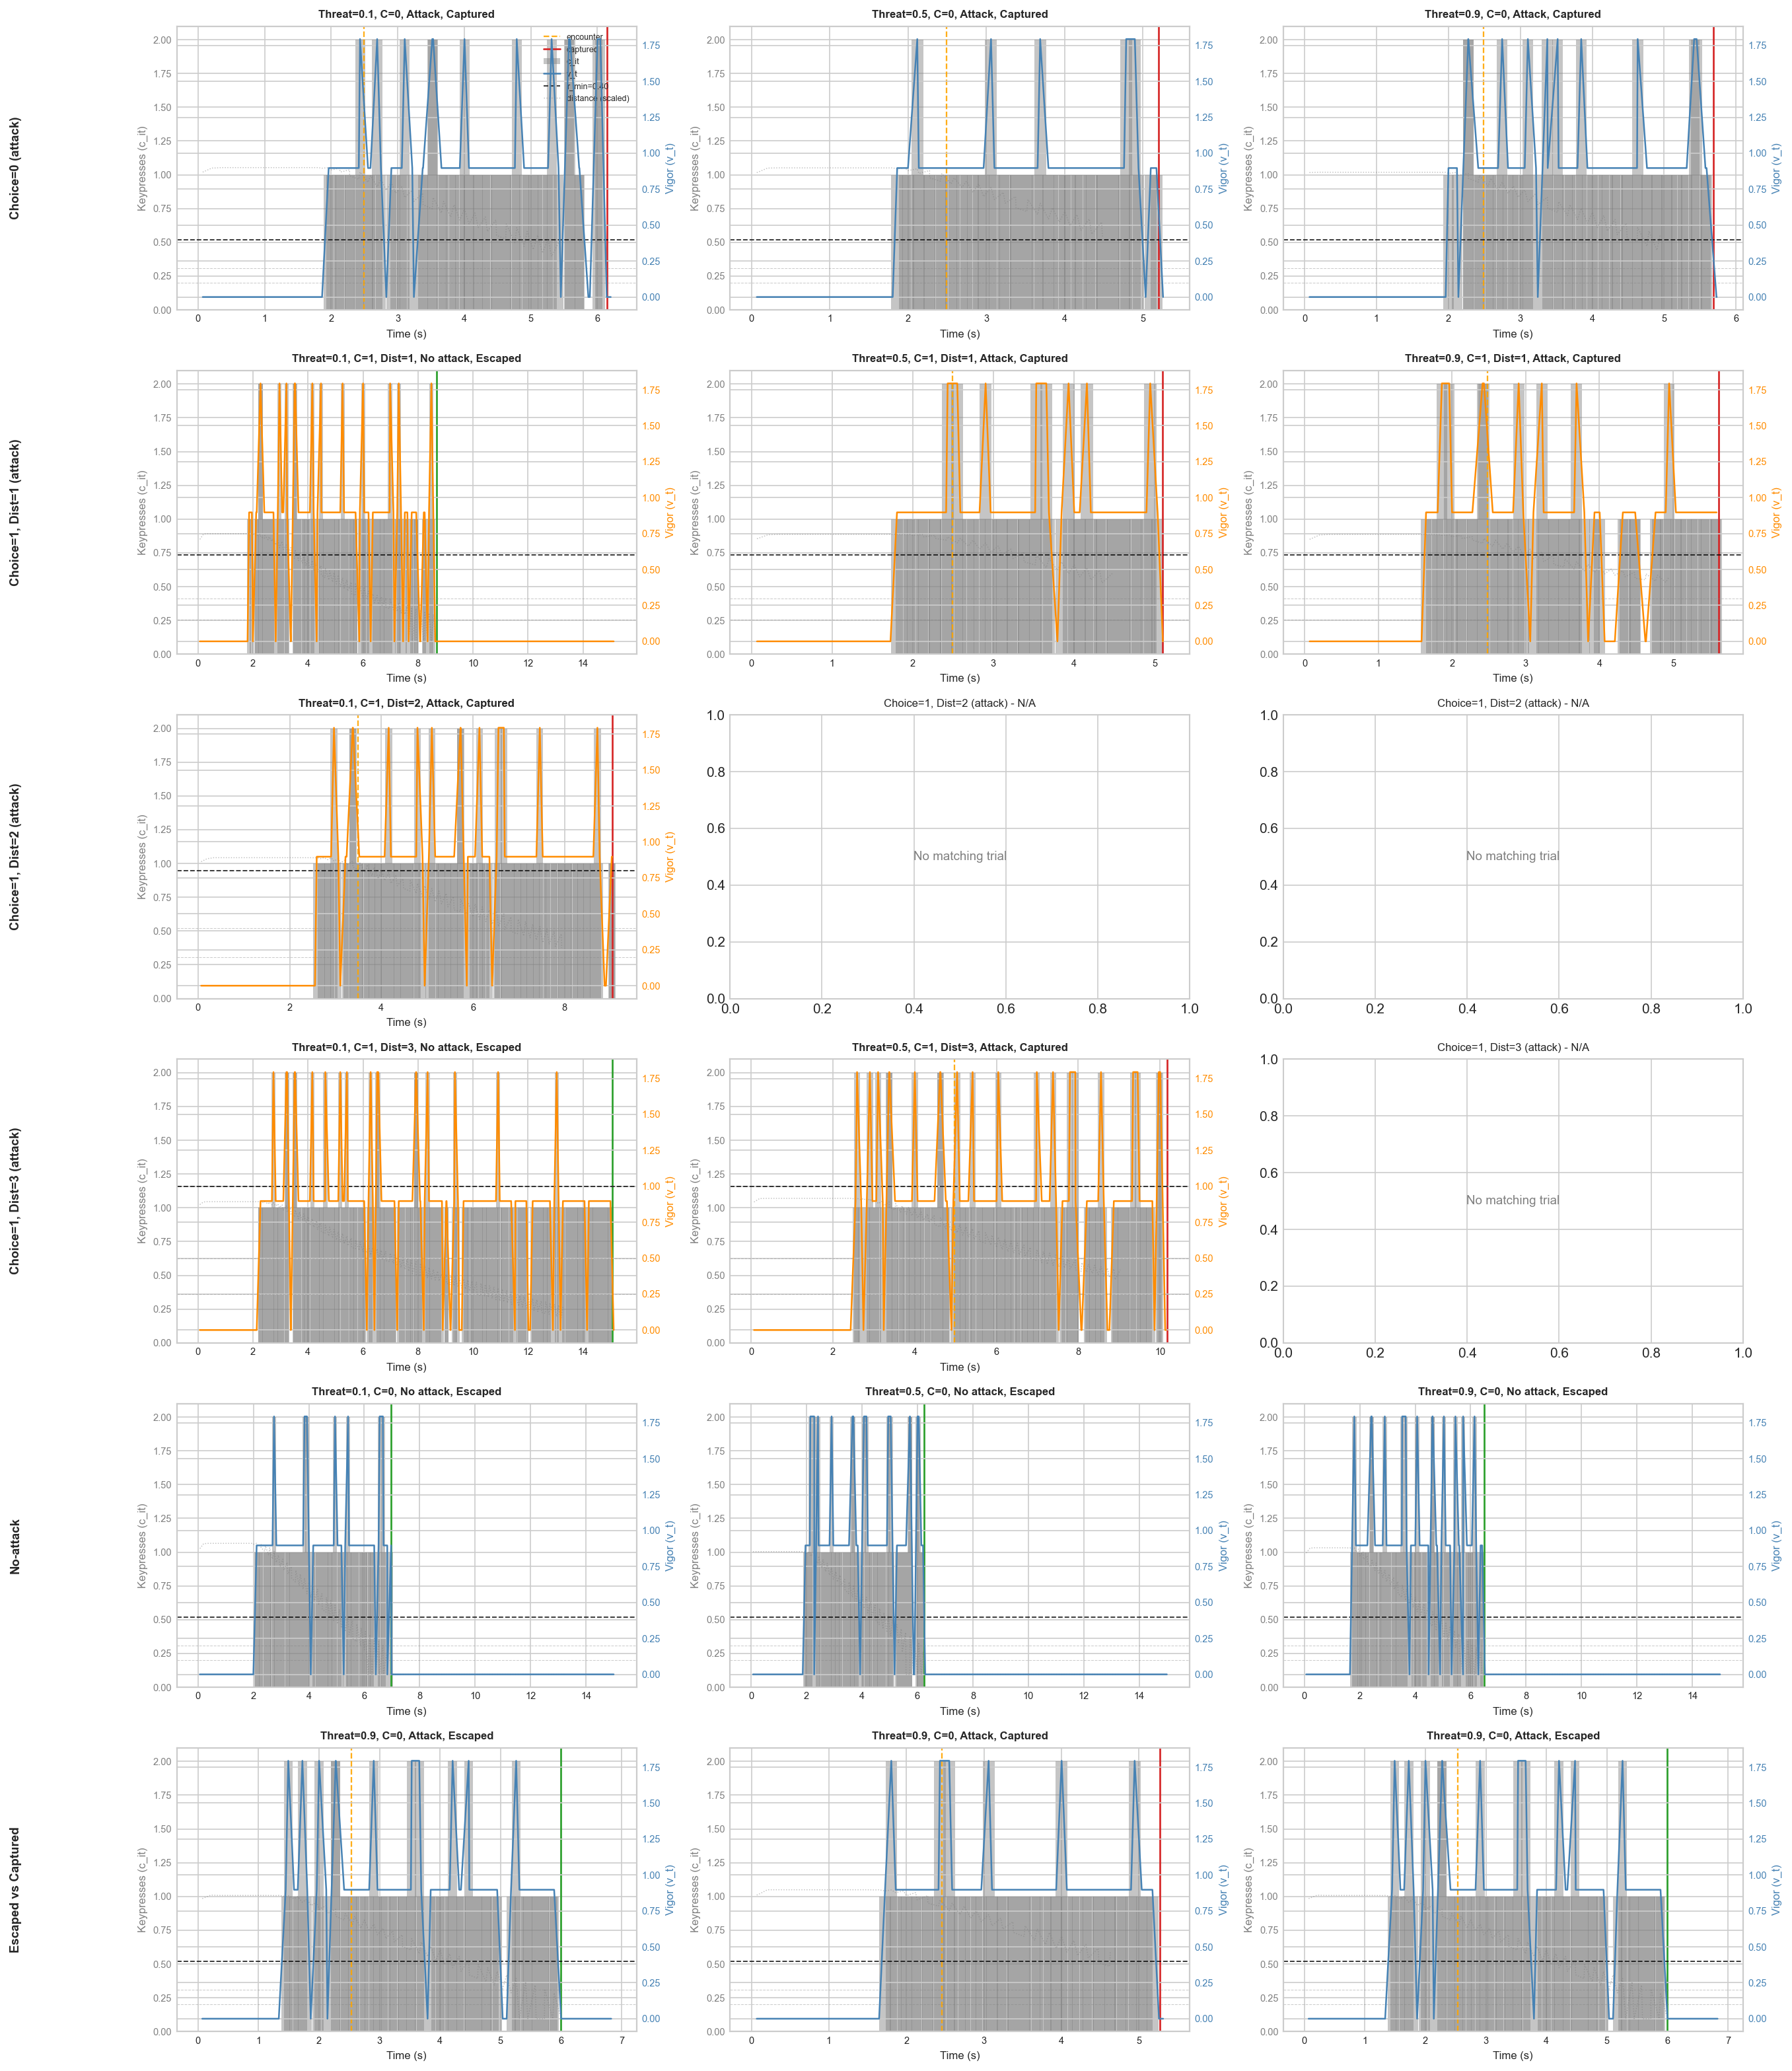

Saved fig01_single_trial_gallery.png


In [4]:
# =============================================================================
# Figure 1: Single-Trial Gallery
# =============================================================================
nrows = len(gallery_rows)
fig, axes = plt.subplots(nrows, 3, figsize=(18, nrows * 3.5), dpi=DPI)

for r, (row_label, row_trials) in enumerate(gallery_rows):
    for c_idx, trial_meta in enumerate(row_trials):
        ax = axes[r, c_idx]
        if trial_meta is None:
            ax.text(0.5, 0.5, 'No matching trial', transform=ax.transAxes,
                    ha='center', va='center', fontsize=9, color='gray')
            ax.set_title(f'{row_label} - N/A', fontsize=8)
            continue

        # Extract time-series for this trial
        sid = trial_meta['subj_id']
        tid = trial_meta['trial_id']
        trial_ts = df[(df['subj_id'] == sid) & (df['trial_id'] == tid)]

        show_leg = (r == 0 and c_idx == 0)
        plot_single_trial(ax, trial_ts, trial_meta, show_legend=show_leg)

    # Row label on left
    axes[r, 0].annotate(row_label, xy=(-0.35, 0.5),
                        xycoords='axes fraction', fontsize=9,
                        fontweight='bold', rotation=90,
                        ha='center', va='center')

plt.tight_layout()
fig.savefig(FIGS_DIR / 'fig01_single_trial_gallery.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved fig01_single_trial_gallery.png')

## Figure 2: Same Condition, Different Subjects
12 subjects spanning vigor percentiles. Each shows one attack trial at threat=0.9, choice=1, distance=2.

In [5]:
# =============================================================================
# Select 12 subjects at different vigor percentiles
# =============================================================================
target_percentiles = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]
vigor_vals = subj_vigor['subj_mean_vigor'].values

selected_subjects = []
used_ids = set()

for pct in target_percentiles:
    target = np.percentile(vigor_vals, pct)
    candidates = subj_vigor[~subj_vigor['subj_id'].isin(used_ids)].copy()
    candidates['dist'] = (candidates['subj_mean_vigor'] - target).abs()
    best = candidates.sort_values('dist').iloc[0]
    selected_subjects.append({
        'subj_id': best['subj_id'],
        'subj_mean_vigor': best['subj_mean_vigor'],
        'percentile': pct,
    })
    used_ids.add(best['subj_id'])

selected_df = pd.DataFrame(selected_subjects)
print(f'Selected {len(selected_df)} subjects at percentiles: {target_percentiles}')

# For each subject, find an attack trial at threat=0.9, choice=1, distance_H=2
fig2_trials = []
for _, srow in selected_df.iterrows():
    sid = srow['subj_id']
    pool = trial_info[trial_info['subj_id'] == sid]

    tr = pick_trial(pool, choice=1, threat=0.9, distance_H=2, encounter=1)
    if tr is None:
        # Fallback: any attack trial choice=1, threat=0.9
        tr = pick_trial(pool, choice=1, threat=0.9, encounter=1)
    if tr is None:
        # Fallback: any attack trial
        tr = pick_trial(pool, encounter=1)
    fig2_trials.append((srow, tr))

n_valid2 = sum(1 for _, tr in fig2_trials if tr is not None)
print(f'{n_valid2} of {len(fig2_trials)} subjects have a matching trial')

Selected 12 subjects at percentiles: [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]
12 of 12 subjects have a matching trial


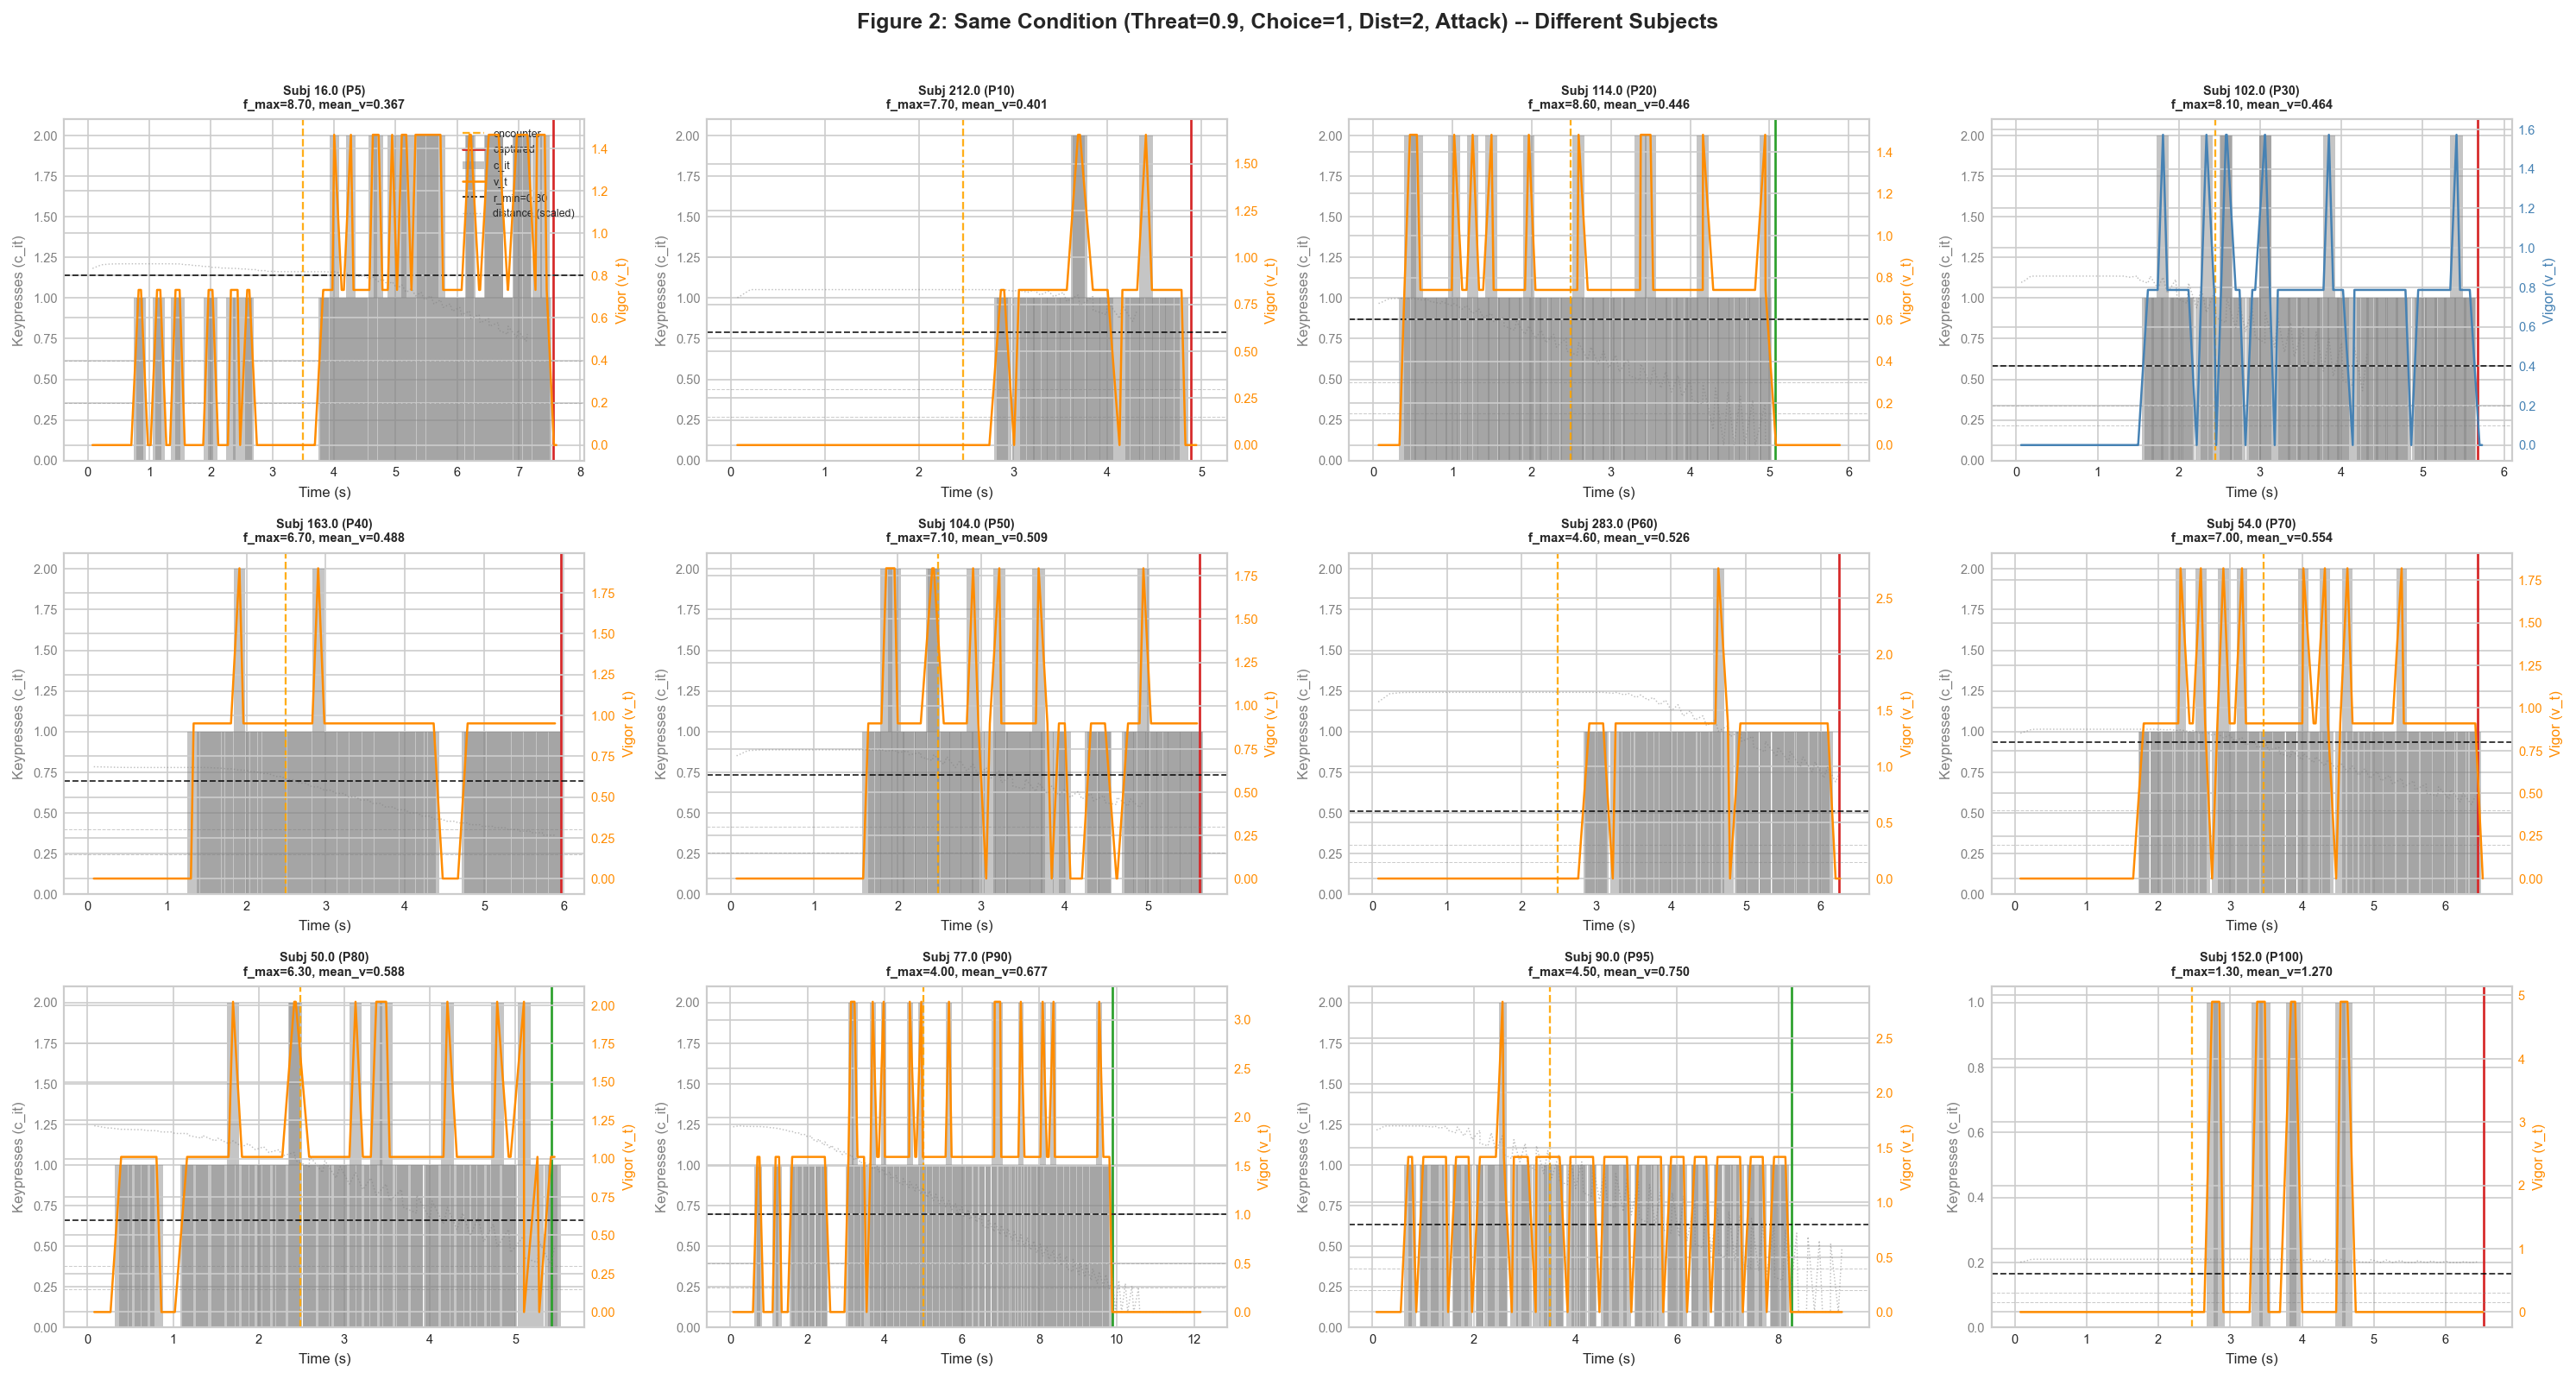

Saved fig02_subject_comparison.png


In [6]:
# =============================================================================
# Figure 2: Same Condition, Different Subjects  (3x4 grid)
# =============================================================================
fig, axes = plt.subplots(3, 4, figsize=(20, 10.5), dpi=DPI)
axes_flat = axes.flatten()

for i, (srow, trial_meta) in enumerate(fig2_trials):
    ax = axes_flat[i]
    if trial_meta is None:
        ax.text(0.5, 0.5, 'No matching trial', transform=ax.transAxes,
                ha='center', va='center', fontsize=9, color='gray')
        ax.set_title(f"Subj {srow['subj_id']} (P{srow['percentile']:.0f})",
                     fontsize=8)
        continue

    sid = trial_meta['subj_id']
    tid = trial_meta['trial_id']
    trial_ts = df[(df['subj_id'] == sid) & (df['trial_id'] == tid)]

    ax2 = plot_single_trial(ax, trial_ts, trial_meta, show_legend=(i == 0))

    # Enhanced title with subject info
    fmax = trial_meta['f_max_i']
    mv = srow['subj_mean_vigor']
    ax.set_title(
        f"Subj {sid} (P{srow['percentile']:.0f})\n"
        f"f_max={fmax:.2f}, mean_v={mv:.3f}",
        fontsize=7, fontweight='bold'
    )

plt.suptitle('Figure 2: Same Condition (Threat=0.9, Choice=1, Dist=2, Attack) -- Different Subjects',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'fig02_subject_comparison.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved fig02_subject_comparison.png')

## Figure 3: Speed Tier Occupancy
What fraction of time is spent at each movement speed tier?

In [7]:
# =============================================================================
# Compute speed tiers and phase labels for every time bin
# =============================================================================

# Merge r_min and terminal_time into the main dataframe
tier_df = df.merge(
    trial_info[['subj_id', 'trial_id', 'r_min', 'terminal_time',
                'encounter_time', 'encounter', 'outcome']],
    on=['subj_id', 'trial_id'],
    how='left',
    suffixes=('', '_ti')
)

# Use the _ti suffixed columns if duplicates arose, otherwise use originals
for col in ['encounter_time', 'encounter', 'outcome']:
    if f'{col}_ti' in tier_df.columns:
        tier_df[col] = tier_df[f'{col}_ti']
        tier_df.drop(columns=[f'{col}_ti'], inplace=True)

# Classify speed tier
tier_df['tier'] = classify_speed_tier_vec(
    tier_df['v_t'].values,
    tier_df['r_min'].values
)

# Phase labels: pre-encounter vs post-encounter
# Pre-encounter: t in [0.5, encounter_time - 0.5]
# Post-encounter: t in [encounter_time, terminal_time] (attack trials only)
def assign_phase(row):
    t = row['t']
    enc = row['encounter']
    enc_t = row['encounter_time']
    term_t = row['terminal_time']
    if enc == 1 and enc_t > 0:
        if 0.5 <= t <= (enc_t - 0.5):
            return 'pre'
        elif enc_t <= t <= term_t:
            return 'post'
        else:
            return 'other'
    else:
        # Non-attack trials: only pre-encounter phase is meaningful
        if 0.5 <= t <= term_t:
            return 'pre'
        else:
            return 'other'

# Vectorised phase assignment for speed
t_vals = tier_df['t'].values
enc_vals = tier_df['encounter'].values
enc_t_vals = tier_df['encounter_time'].values
term_t_vals = tier_df['terminal_time'].values

phase = np.full(len(tier_df), 'other', dtype=object)

# Attack trials
is_attack = (enc_vals == 1) & (enc_t_vals > 0)
phase[is_attack & (t_vals >= 0.5) & (t_vals <= (enc_t_vals - 0.5))] = 'pre'
phase[is_attack & (t_vals >= enc_t_vals) & (t_vals <= term_t_vals)] = 'post'

# Non-attack trials
is_no_attack = ~is_attack
phase[is_no_attack & (t_vals >= 0.5) & (t_vals <= term_t_vals)] = 'pre'

tier_df['phase'] = phase

# Filter to pre/post only
tier_phase = tier_df[tier_df['phase'].isin(['pre', 'post'])].copy()
print(f'Tier data (pre/post only): {len(tier_phase):,} time bins')
print('Phase counts:')
print(tier_phase['phase'].value_counts())

Tier data (pre/post only): 1,178,266 time bins
Phase counts:
phase
pre     885192
post    293074
Name: count, dtype: int64


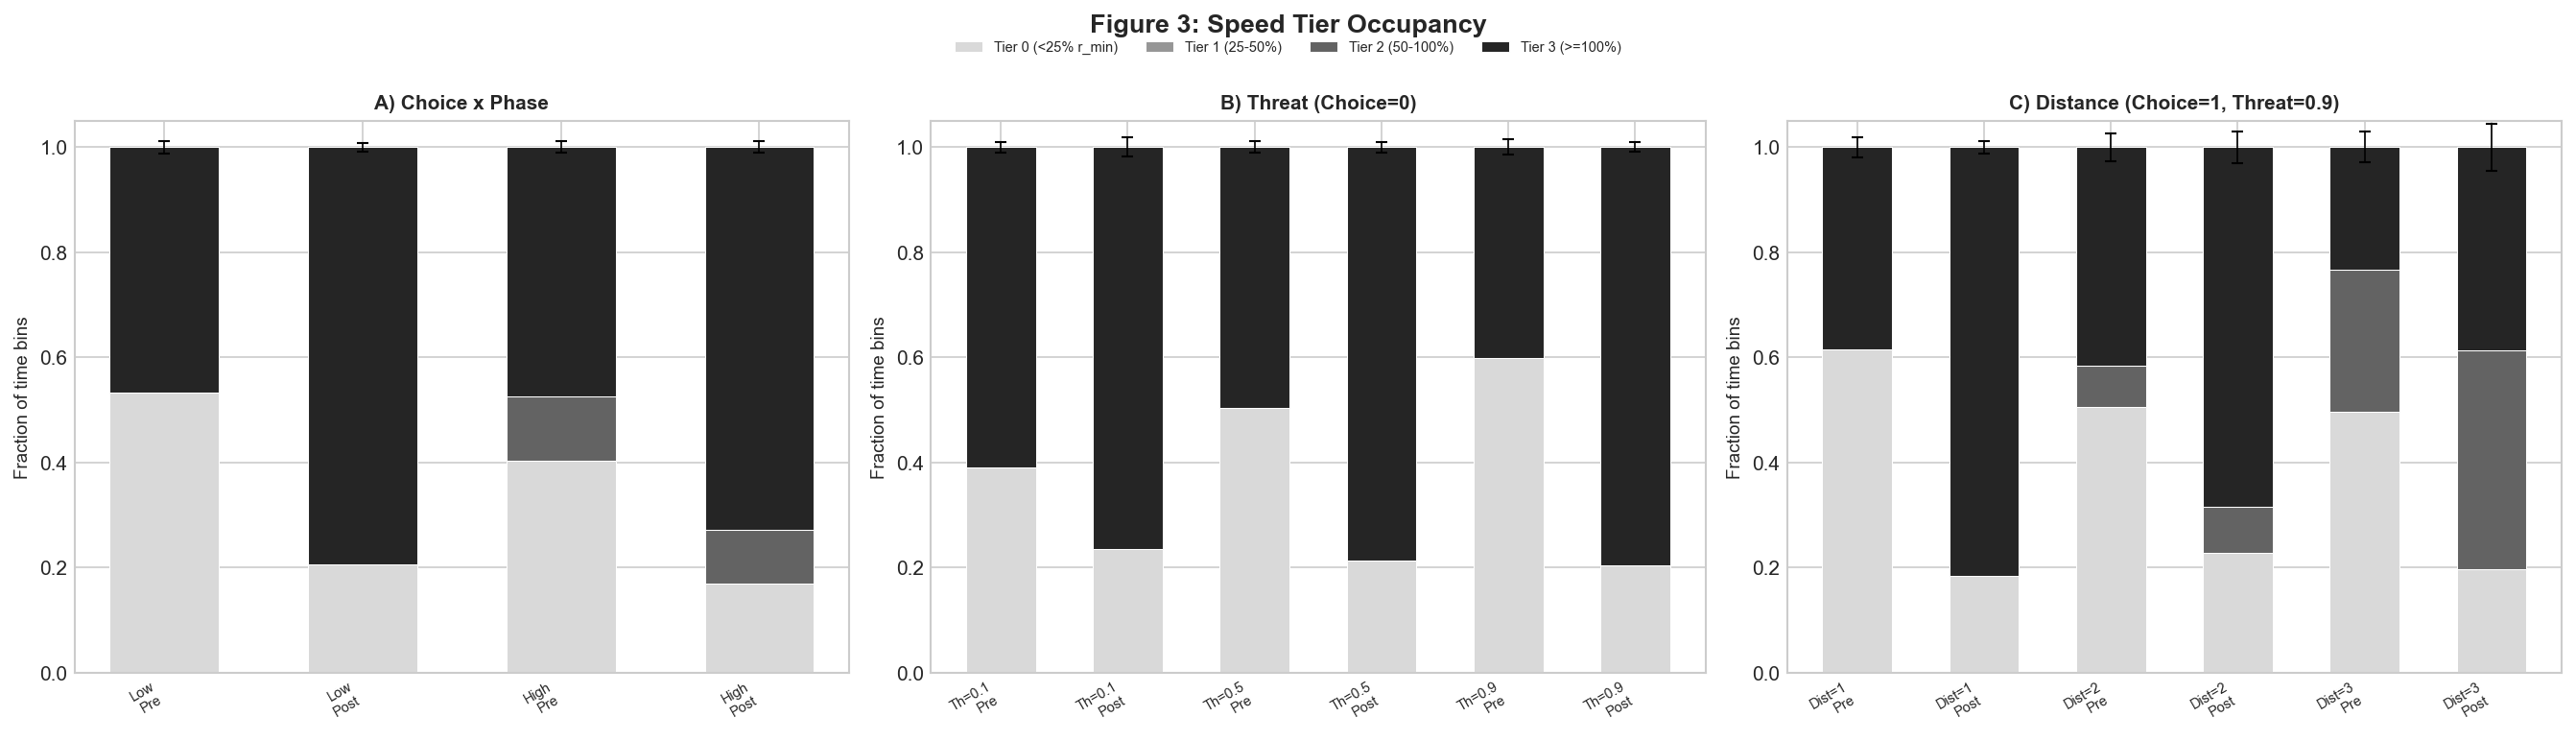

Saved fig03_speed_tier_occupancy.png


In [9]:
# =============================================================================
# Figure 3: Speed Tier Occupancy  (3 panels)
# =============================================================================

def compute_tier_fractions(subset, group_cols):
    """
    Compute mean +/- SEM of tier fractions.
    1) Per trial: count bins in each tier -> fraction.
    2) Average by subject within each group.
    3) Average across subjects -> mean, SEM.
    """
    # Trial-level tier counts
    trial_counts = (subset.groupby(['subj_id', 'trial_id'] + group_cols)['tier']
                    .value_counts(normalize=True)
                    .unstack(fill_value=0)
                    .reset_index())
    # Ensure all tiers present
    for ti in range(4):
        if ti not in trial_counts.columns:
            trial_counts[ti] = 0.0

    # Subject-level means
    subj_means = (trial_counts.groupby(['subj_id'] + group_cols)[[0,1,2,3]]
                  .mean().reset_index())

    # Grand mean + SEM across subjects
    grand = subj_means.groupby(group_cols)[[0,1,2,3]].agg(['mean', 'sem']).reset_index()
    return grand


def plot_stacked_bars(ax, data, group_labels, title, tier_colors=TIER_COLORS):
    """
    Draw a stacked bar chart of tier fractions with SEM error bars on top tier.
    data: list of dicts, each with keys 'mean' and 'sem' for tiers 0-3.
    """
    n_groups = len(group_labels)
    x = np.arange(n_groups)
    width = 0.55

    bottoms = np.zeros(n_groups)
    for tier_idx in range(4):
        heights = np.array([d['mean'][tier_idx] for d in data])
        sems = np.array([d['sem'][tier_idx] for d in data])
        bars = ax.bar(x, heights, width, bottom=bottoms,
                      color=tier_colors[tier_idx],
                      label=TIER_LABELS[tier_idx],
                      edgecolor='white', linewidth=0.5)
        # Error bars on top tier only
        if tier_idx == 3:
            ax.errorbar(x, bottoms + heights, yerr=sems, fmt='none',
                        ecolor='black', elinewidth=0.8, capsize=3)
        bottoms += heights

    ax.set_xticks(x)
    ax.set_xticklabels(group_labels, fontsize=7, rotation=30, ha='right')
    ax.set_ylabel('Fraction of time bins', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=10, fontweight='bold')


# ------------------------------------------------------------------
# Panel A: choice x phase (attack trials only for post-encounter)
# ------------------------------------------------------------------
# For pre-encounter: use all trials (attack + non-attack)
# For post-encounter: attack trials only
attack_trials_ids = set(
    zip(trial_info[trial_info['encounter'] == 1]['subj_id'],
        trial_info[trial_info['encounter'] == 1]['trial_id'])
)

panelA_data = []
panelA_labels = []

for ch in [0, 1]:
    for ph in ['pre', 'post']:
        subset = tier_phase[(tier_phase['choice'] == ch) & (tier_phase['phase'] == ph)].copy()
        if ph == 'post':
            # Only attack trials for post-encounter
            mask = subset.apply(
                lambda r: (r['subj_id'], r['trial_id']) in attack_trials_ids, axis=1
            ) if len(subset) < 200000 else pd.Series(
                [(s, t) in attack_trials_ids for s, t in zip(subset['subj_id'], subset['trial_id'])],
                index=subset.index
            )
            subset = subset[mask]
        if len(subset) == 0:
            continue

        # Trial-level tier fractions
        trial_fracs = (subset.groupby(['subj_id', 'trial_id'])['tier']
                       .value_counts(normalize=True)
                       .unstack(fill_value=0)
                       .reset_index())
        for ti in range(4):
            if ti not in trial_fracs.columns:
                trial_fracs[ti] = 0.0

        # Subject means
        subj_m = trial_fracs.groupby('subj_id')[[0,1,2,3]].mean()
        grand_mean = subj_m.mean()
        grand_sem = subj_m.sem()

        panelA_data.append({
            'mean': {i: grand_mean[i] for i in range(4)},
            'sem': {i: grand_sem[i] for i in range(4)},
        })
        ch_label = 'Low' if ch == 0 else 'High'
        panelA_labels.append(f'{ch_label}\n{ph.capitalize()}')

# ------------------------------------------------------------------
# Panel B: by threat (choice=0, attack trials only for post-enc)
# ------------------------------------------------------------------
panelB_data = []
panelB_labels = []

for th in [0.1, 0.5, 0.9]:
    for ph in ['pre', 'post']:
        subset = tier_phase[(tier_phase['choice'] == 0) &
                            (tier_phase['threat'] == th) &
                            (tier_phase['phase'] == ph)].copy()
        if ph == 'post':
            mask = pd.Series(
                [(s, t) in attack_trials_ids for s, t in zip(subset['subj_id'], subset['trial_id'])],
                index=subset.index
            )
            subset = subset[mask]
        if len(subset) == 0:
            continue

        trial_fracs = (subset.groupby(['subj_id', 'trial_id'])['tier']
                       .value_counts(normalize=True)
                       .unstack(fill_value=0)
                       .reset_index())
        for ti in range(4):
            if ti not in trial_fracs.columns:
                trial_fracs[ti] = 0.0

        subj_m = trial_fracs.groupby('subj_id')[[0,1,2,3]].mean()
        grand_mean = subj_m.mean()
        grand_sem = subj_m.sem()

        panelB_data.append({
            'mean': {i: grand_mean[i] for i in range(4)},
            'sem': {i: grand_sem[i] for i in range(4)},
        })
        panelB_labels.append(f'Th={th}\n{ph.capitalize()}')

# ------------------------------------------------------------------
# Panel C: by distance (choice=1, threat=0.9, attack trials)
# ------------------------------------------------------------------
panelC_data = []
panelC_labels = []

for di in [1, 2, 3]:
    for ph in ['pre', 'post']:
        subset = tier_phase[(tier_phase['choice'] == 1) &
                            (tier_phase['threat'] == 0.9) &
                            (tier_phase['distance_H'] == di) &
                            (tier_phase['phase'] == ph)].copy()
        if ph == 'post':
            mask = pd.Series(
                [(s, t) in attack_trials_ids for s, t in zip(subset['subj_id'], subset['trial_id'])],
                index=subset.index
            )
            subset = subset[mask]
        if len(subset) == 0:
            continue

        trial_fracs = (subset.groupby(['subj_id', 'trial_id'])['tier']
                       .value_counts(normalize=True)
                       .unstack(fill_value=0)
                       .reset_index())
        for ti in range(4):
            if ti not in trial_fracs.columns:
                trial_fracs[ti] = 0.0

        subj_m = trial_fracs.groupby('subj_id')[[0,1,2,3]].mean()
        grand_mean = subj_m.mean()
        grand_sem = subj_m.sem()

        panelC_data.append({
            'mean': {i: grand_mean[i] for i in range(4)},
            'sem': {i: grand_sem[i] for i in range(4)},
        })
        panelC_labels.append(f'Dist={di}\n{ph.capitalize()}')

# ------------------------------------------------------------------
# Draw Figure 3
# ------------------------------------------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=DPI)

plot_stacked_bars(ax1, panelA_data, panelA_labels,
                  'A) Choice x Phase')
fig.legend(*ax1.get_legend_handles_labels(), fontsize=7,
           loc='upper center', bbox_to_anchor=(0.5, 1.0),
           ncol=4, framealpha=0.8)
plot_stacked_bars(ax2, panelB_data, panelB_labels,
                  'B) Threat (Choice=0)')

plot_stacked_bars(ax3, panelC_data, panelC_labels,
                  'C) Distance (Choice=1, Threat=0.9)')

plt.suptitle('Figure 3: Speed Tier Occupancy', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIGS_DIR / 'fig03_speed_tier_occupancy.png',
            dpi=DPI, bbox_inches='tight')
plt.show()
print('Saved fig03_speed_tier_occupancy.png')

## Summary
Key observations from single-trial visualization:

- **Figure 1** reveals the rich within-trial dynamics: keypresses arrive in bursts, vigor fluctuates
  around the r_min threshold, and the encounter event triggers distinct behavioral regimes.
- **Figure 2** demonstrates substantial individual differences in motor vigor even under identical
  task conditions, motivating subject-level parameters (f_max_i) in computational models.
- **Figure 3** quantifies how much time subjects spend in each speed tier, revealing that the
  majority of time is spent below the required speed, with tier occupancy shifting after encounters
  and across threat/distance conditions.